In [22]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [3]:
Main.eval('using Distributed')
Main.eval('addprocs(8)') 

array([2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

Choose NP strong coupling prescription

In [4]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles      
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
    end
""")

Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\SCET.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("cross section.jl")
#Main.include("NP.jl")

Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

In [87]:
error_type = "both"

In [88]:
df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

Range Choice

In [ ]:
χ_lower = 0.0
χ_upper = 90
kt_lower = 0
kt_upper = 100
sqrtz_lower = 0
sqrtz_upper = 1/3

#-------------------------------------------------------------------
#dataset_names = ["MARKII"]
#-------------------------------------------------------------------
#-------------------------------------------------------------------
dataset_names = ["OPAL_new","SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------
 
df_all = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["ERROR"]
    Q = df["Q"]
    
    df = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q})
    df_all[name] = df

bin_list = {}
bin_list["SLD"]       = 3.6
bin_list["OPAL"]      = 1.8
bin_list["OPAL_new"]  = 1.0
bin_list["DELPHI"]    = 3.6
bin_list["TOPAZ_595"] = 3.6
bin_list["TOPAZ_533"] = 3.6
bin_list["TASSO_435"] = 3.6
bin_list["TASSO_348"] = 3.6
bin_list["MARKII"]    = 3.6
bin_list["MAC"]       = 3.6
bin_list["TASSO_220"] = 3.6
bin_list["TASSO_140"] = 3.6

#for name in dataset_names:
#    if error_type == "both":
#        Q = Q_list[name]
#        αs = Main.alpha_s_func(μf=Q, μi=91.1876, αs=0.118, order=4, nf=5)
#        a = αs/(2*np.pi)
#
#        fixed_error=[]
#        for angle in df[name]["CHI"]:
#            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
#            fixed_error.append(value)
#
#        df[name]["ERROR"] = np.sqrt(df[name]["ERROR"]**2 + np.array(fixed_error)**2)

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*Q_list[name]

    df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower) & 
                                  (sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower) &
                                  (df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

    

{'OPAL_new':      CHI     EEC     ERROR
 0    1.5  0.9330  0.227070
 1    2.5  1.2890  0.088868
 2    3.5  1.3830  0.169453
 3    4.5  1.3400  0.157117
 4    5.5  1.2580  0.087094
 5    6.5  1.1490  0.058141
 6    7.5  1.0370  0.035124
 7    8.5  0.9330  0.021206
 8    9.5  0.8390  0.022129
 9   10.5  0.7580  0.025113
 10  11.5  0.6900  0.020112
 11  12.5  0.6260  0.014160
 12  13.5  0.5680  0.013126
 13  14.5  0.5193  0.009333
 14  15.5  0.4732  0.004767
 15  16.5  0.4330  0.012093
 16  17.5  0.3960  0.014080
 17  18.5  0.3662  0.009605
 18  19.5  0.3367  0.005293
 19  20.5  0.3103  0.006537
 20  21.5  0.2880  0.011080
 21  22.5  0.2690  0.007400
 22  23.5  0.2526  0.005523
 23  24.5  0.2372  0.005817
 24  25.5  0.2239  0.008874
 25  26.5  0.2119  0.004546
 26  27.5  0.2011  0.002613
 27  28.5  0.1927  0.003938
 28  29.5  0.1835  0.003645
 29  30.5  0.1753  0.002244
 30  31.5  0.1678  0.002594
 31  32.5  0.1617  0.002681
 32  33.5  0.1564  0.003153
 33  34.5  0.1494  0.001953
 34  35.

38

10

10

10

10

10

10

10

Chi-Square calculation

In [90]:
def DELTA_func(ylist,PRED):

    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

#def DELTA_func(ylist,PRED):
#    l = len(ylist)
#    theory = np.zeros(l)
#    for i in range(l):
#        simpson = PRED[0][i] 
#        theory[i] = np.nan_to_num(simpson,nan=0.0)
#    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

import sys
def objective(params, df, Q_list, bin_list, dataset_names, if_renormalon):

    #----------
    XLL = 2 #1 for NLL
    #----------

    #N = 1
    N = 5
    
    chi2 = 0
    length = 0
    
    αs = params[0]
    params_noαs = params[1:]

    for name in dataset_names:

        xlist={}
        xlist_mid=np.array(df[name]["CHI"])
        binsize=bin_list[name] # Evenly sized bins assumed
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        #xlist={}
        #xlist_mid=np.array(df[name]["CHI"])
        #for i in range(N):
        #    xlist[i]=xlist_mid

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        l = len(xlist_mid)
        length = length + l

        PRED={}

        if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            for quartile in range(N):
                PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], order=XLL, params=parameters, Ω1=Ω1)
            DELTA =  DELTA_func(ylist,PRED)
        else:
            parameters = params_noαs
            for quartile in range(N):
                PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], order=XLL, params=parameters)                
            DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/length

import csv
import sys

class ProgressCallback:
    def __init__(self, df, Q_list, bin_list, dataset_names, if_renormalon, csv_file='record.csv'):
        self.df = df
        self.Q_list = Q_list
        self.bin_list = bin_list      
        self.dataset_names = dataset_names
        self.if_renormalon = if_renormalon
        self.iteration = 0
        self.csv_file = csv_file

        with open(self.csv_file, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Iteration"] + [f"Param_{i+1}" for i in range(len(Q_list))] + ["Chi2/dof"])

    def __call__(self, params):
        self.iteration += 1
        chi2_bydof = objective(params, self.df, self.Q_list, self.bin_list, self.dataset_names, self.if_renormalon)
        
        print(f"Iteration: {self.iteration}, Params: {params}, Chi2/dof: {chi2_bydof}")
        sys.stdout.flush()

        with open(self.csv_file, mode='a', newline='') as file:
            writer = csv.writer(file)
            writer.writerow([self.iteration] + list(params) + [chi2_bydof])


class MyBounds:
    def __init__(self, xmax, xmin):
        self.xmax = np.array(xmax)
        self.xmin = np.array(xmin)

    def __call__(self, **kwargs):
        x = kwargs["x_new"]
        tmax = bool(np.all(x <= self.xmax))
        tmin = bool(np.all(x >= self.xmin))
        return tmax and tmin
    
if_renormalon = False

In [91]:
def set_NP(ansatz: str):
    body = ansatz

    julia_code = f"""
    @everywhere begin
        function NP(; z::Float64, b::Float64, ζi::Float64, ζf::Float64, params::Vector{{Float64}})
            a = params
            NP = {body}
            return NP
        end
    end
    """
    Main.eval(julia_code)

In [92]:
df_ansatzes = pd.DataFrame([
    {"ansatz": "exp(-(a[1]*b^2+a[2]*b))", 
     "params": [0.118, 1.0, 1.0]},

    {"ansatz": "1/(1+a[1]*b^a[2])", 
     "params": [0.118, 1.0, 1.0]},

    {"ansatz": "exp(-(a[1]*b^a[2]))", 
     "params": [0.118, 1.0, 1.0]},    

    {"ansatz": "(a[2]*b)^(-a[1])*besselj(a[1], a[2]*b)/((2^(-a[1]))/gamma(1 + a[1]))", 
     "params": [0.118, 1.0, 1.0]},  

    {"ansatz": "(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a[1]-1)*gamma(a[1]))", 
     "params": [0.118, 1.0, 1.0]},   

    {"ansatz": "exp(-(a[1]*b^2+a[2]*b+a[3]))", 
     "params": [0.118, 1.0, 1.0, 1.0]},

    {"ansatz": "exp(-(a[1]*b^a[2]+a[3]))", 
     "params": [0.118, 1.0, 1.0, 1.0]},

    {"ansatz": "a[3]*(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a[1]-1)*gamma(a[1]))", 
     "params": [0.118, 1.0, 1.0, 1.0]},

    {"ansatz": "a[3]/(1+a[1]*b^a[2])", 
     "params": [0.118, 1.0, 1.0, 1.0]}, 

    {"ansatz": "exp(-(a[1]*b^2+a[2]*b+a[3]*sqrt(b)))", 
     "params": [0.118, 1.0, 1.0, 1.0]},  

    {"ansatz": "exp(-(a[1]*b^2+a[2]*b))*(1+a[3]*b)", 
     "params": [0.118, 1.0, 1.0, 1.0]},                       

    {"ansatz": "exp(-(a[1]*b^a[2]))*(1+a[3]*b)", 
     "params": [0.118, 1.0, 1.0, 1.0]},

    {"ansatz": "a[3]*(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a[1]-1)*gamma(a[1]))*(1+a[3]*b)", 
     "params": [0.118, 1.0, 1.0, 1.0]},

    {"ansatz": "exp(-(a[1]*b^a[2]))*(1+a[3]*b^a[4])", 
     "params": [0.118, 1.0, 1.0, 0.0, 0.0]},

    {"ansatz": "exp(-(a[1]*b^2+a[2]*b))*(1+a[3]*b^a[4])", 
     "params": [0.118, 1.0, 1.0, 0.0, 0.0]},

    {"ansatz": "exp(-(a[1]*b^2+a[2]*b))*(1+a[3]*b^a[4])", 
     "params": [0.118, 1.0, 1.0, 0.0, 0.0]},

    {"ansatz": "exp(-(a[1]*b^a[2]))/(1+a[3]*b^a[4])", 
     "params": [0.118, 1.0, 1.0, 0.0, 0.0]},                   

    {"ansatz": "exp(-(a[1]*b^a[2]+a[3]*b^a[4]))", 
     "params": [0.118, 1.0, 1.0, 0.0, 0.0]},             
])
display(df_ansatzes)

,ansatz,params
0,exp(-(a[1]*b^2+a[2]*b)),"[0.118, 1.0, 1.0]"
1,1/(1+a[1]*b^a[2]),"[0.118, 1.0, 1.0]"
2,exp(-(a[1]*b^a[2])),"[0.118, 1.0, 1.0]"
3,"(a[2]*b)^(-a[1])*besselj(a[1], a[2]*b)/((2^(-a...","[0.118, 1.0, 1.0]"
4,"(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a[1]-1...","[0.118, 1.0, 1.0]"
5,exp(-(a[1]*b^2+a[2]*b+a[3])),"[0.118, 1.0, 1.0, 1.0]"
6,exp(-(a[1]*b^a[2]+a[3])),"[0.118, 1.0, 1.0, 1.0]"
7,"a[3]*(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a...","[0.118, 1.0, 1.0, 1.0]"
8,a[3]/(1+a[1]*b^a[2]),"[0.118, 1.0, 1.0, 1.0]"
9,exp(-(a[1]*b^2+a[2]*b+a[3]*sqrt(b))),"[0.118, 1.0, 1.0, 1.0]"


In [93]:
for nth in range(len(df_ansatzes)):
    set_NP(df_ansatzes["ansatz"].iloc[nth])
    chi2 = objective(df_ansatzes["params"].iloc[nth], df_truncated, Q_list, bin_list, dataset_names, False)
    print(chi2)

54.69987611426515
78.34415004202548
66.05608438966165
199.90317607669968
185.53483198650957
576.0486815100602
616.3590260095452
185.53483198650957
78.34415004202548
21.97961046815663
219.4030597279779
216.84192306506353
446.1300979197585
66.05608438966165
54.69987611426515
54.69987611426515
66.05608438966165
66.05608438966165


In [94]:
def round_sig(x, sig=3):
    if isinstance(x, np.ndarray):
        return np.array([round_sig(val, sig) for val in x])
    elif isinstance(x, list):
        return [round_sig(val, sig) for val in x]
    elif x == 0:
        return 0
    else:
        return round(x, sig - int(np.floor(np.log10(abs(x)))) - 1)

Local then hopping

In [95]:
χ_lower_list = [0.0]
χ_upper_list = [90]#[35,40,45,50,55,60]
sqrtz_lower_list = [0]
sqrtz_upper_list = [1/3]
kt_lower_list = [0]
kt_upper_list = [100]#[5,10,15]

In [86]:
result_df = pd.DataFrame(columns=["ansatz","χ_l", "χ_u", "sqrtz_l", "sqrtz_u", "kt_d", "kt_u", "params", "χ2/N"])

for nth in range(len(df_ansatzes)):
    for χ_lower in χ_lower_list:
        for χ_upper in χ_upper_list:
            for kt_lower in kt_lower_list:
                for kt_upper in kt_upper_list:
                    for sqrtz_lower in sqrtz_lower_list:
                        for sqrtz_upper in sqrtz_upper_list:

                            set_NP(df_ansatzes["ansatz"].iloc[nth])

                            df_truncated = {}
                            χ = {}
                            EEC = {}
                            ERROR = {}

                            for name in dataset_names:
                                kt_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)*Q_list[name]
                                df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower) & 
                                            (sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower) &
                                            (df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
                                
                                χ[name] = np.array(df_truncated[name]["CHI"])
                                EEC[name] = np.array(df_truncated[name]["EEC"])
                                ERROR[name] = np.array(df_truncated[name]["ERROR"])

                            initial_params = df_ansatzes["params"].iloc[nth]

                            bounds = []
                            bounds.append([0.118,0.118])
                            bounds.append([0.0,10.0])
                            bounds.append([0.0,10.0])                                                                                
                            for i in range(len(initial_params)-3):
                                    bounds.append([-10.0, 10.0])

                            bounds_T = [list(t) for t in zip(*bounds)]

                            progress_callback = ProgressCallback(df_truncated, Q_list, bin_list, dataset_names, if_renormalon)

                            minimizer_kwargs = {
                                "method": "L-BFGS-B",
                                "bounds": bounds,
                                "args": (df_truncated, Q_list, bin_list, dataset_names, if_renormalon),
                                "options": {'maxiter': 100, 'disp': True, "ftol": 10**(-9)},
                                "callback": progress_callback
                            }

                            result = basinhopping(
                                objective,
                                initial_params,
                                minimizer_kwargs=minimizer_kwargs,
                                niter=0,
                                accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
                            )

                            optimal_params = result.x
                            #print(f"Optimal parameters: {optimal_params}")
                            
                            result_df.loc[len(result_df)] = [df_ansatzes["ansatz"].iloc[nth], χ_lower, χ_upper, sqrtz_lower, sqrtz_upper, kt_lower, kt_upper, round_sig(optimal_params), round_sig(result.fun)]

result_df.to_csv("result.csv", index=False)
display(result_df)

Iteration: 1, Params: [0.118      1.77475673 1.77475673], Chi2/dof: 39.76295399369421
Iteration: 2, Params: [0.118      1.53348011 1.79971658], Chi2/dof: 35.188506112818196
Iteration: 3, Params: [0.118      0.         2.26677471], Chi2/dof: 17.435097164137254
Iteration: 4, Params: [0.118      0.         2.42918541], Chi2/dof: 16.568390150066634
Iteration: 5, Params: [0.118      0.         2.43623384], Chi2/dof: 16.566716981370526
Iteration: 6, Params: [0.118      0.         2.43689902], Chi2/dof: 16.566704383429578
Iteration: 7, Params: [0.118     0.        2.4369017], Chi2/dof: 16.566704383219992
Iteration: 1, Params: [0.118      2.43498873 0.84055681], Chi2/dof: 37.74370444846338
Iteration: 2, Params: [0.118      2.69881599 1.07568274], Chi2/dof: 24.306400037073963
Iteration: 3, Params: [0.118      2.88125369 1.08320937], Chi2/dof: 22.493624421296666
Iteration: 4, Params: [0.118      3.38951447 1.11269947], Chi2/dof: 19.921423536738388
Iteration: 5, Params: [0.118      3.59912937 1.1

,ansatz,χ_l,χ_u,sqrtz_l,sqrtz_u,kt_d,kt_u,params,χ2/N
0,exp(-(a[1]*b^2+a[2]*b)),0.0,90,0,0.333333,0,100,"[0.118, 0.0, 2.44]",16.60
1,1/(1+a[1]*b^a[2]),0.0,90,0,0.333333,0,100,"[0.118, 3.7, 1.14]",19.60
2,exp(-(a[1]*b^a[2])),0.0,90,0,0.333333,0,100,"[0.118, 2.22, 0.871]",12.10
3,"(a[2]*b)^(-a[1])*besselj(a[1], a[2]*b)/((2^(-a...",0.0,90,0,0.333333,0,100,"[0.118, 0.0, 0.559]",147.00
4,"(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a[1]-1...",0.0,90,0,0.333333,0,100,"[0.118, 0.375, 2.01]",10.00
5,exp(-(a[1]*b^2+a[2]*b+a[3])),0.0,90,0,0.333333,0,100,"[0.118, 0.937, 2.07, 0.139]",1.69
6,exp(-(a[1]*b^a[2]+a[3])),0.0,90,0,0.333333,0,100,"[0.118, 2.78, 1.17, 0.162]",1.53
7,"a[3]*(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a...",0.0,90,0,0.333333,0,100,"[0.118, 0.725, 3.13, 0.84]",1.65
8,a[3]/(1+a[1]*b^a[2]),0.0,90,0,0.333333,0,100,"[0.118, 5.99, 1.64, 0.829]",4.19
9,exp(-(a[1]*b^2+a[2]*b+a[3]*sqrt(b))),0.0,90,0,0.333333,0,100,"[0.118, 1.93, 0.611, 0.881]",3.72


In [96]:
result_df = pd.DataFrame(columns=["ansatz","χ_l", "χ_u", "sqrtz_l", "sqrtz_u", "kt_d", "kt_u", "params", "χ2/N"])

for nth in range(len(df_ansatzes)):
    for χ_lower in χ_lower_list:
        for χ_upper in χ_upper_list:
            for kt_lower in kt_lower_list:
                for kt_upper in kt_upper_list:
                    for sqrtz_lower in sqrtz_lower_list:
                        for sqrtz_upper in sqrtz_upper_list:

                            set_NP(df_ansatzes["ansatz"].iloc[nth])

                            df_truncated = {}
                            χ = {}
                            EEC = {}
                            ERROR = {}

                            for name in dataset_names:
                                kt_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)*Q_list[name]
                                df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower) & 
                                            (sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower) &
                                            (df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
                                
                                χ[name] = np.array(df_truncated[name]["CHI"])
                                EEC[name] = np.array(df_truncated[name]["EEC"])
                                ERROR[name] = np.array(df_truncated[name]["ERROR"])

                            initial_params = df_ansatzes["params"].iloc[nth]

                            bounds = []
                            bounds.append([0.118,0.118])
                            bounds.append([0.0,10.0])
                            bounds.append([0.0,10.0])                                                                                
                            for i in range(len(initial_params)-3):
                                    bounds.append([-10.0, 10.0])

                            bounds_T = [list(t) for t in zip(*bounds)]

                            progress_callback = ProgressCallback(df_truncated, Q_list, bin_list, dataset_names, if_renormalon)

                            minimizer_kwargs = {
                                "method": "L-BFGS-B",
                                "bounds": bounds,
                                "args": (df_truncated, Q_list, bin_list, dataset_names, if_renormalon),
                                "options": {'maxiter': 100, 'disp': True, "ftol": 10**(-9)},
                                "callback": progress_callback
                            }

                            result = basinhopping(
                                objective,
                                initial_params,
                                minimizer_kwargs=minimizer_kwargs,
                                niter=0,
                                accept_test=MyBounds(xmax=bounds_T[1],xmin=bounds_T[0])
                            )

                            optimal_params = result.x
                            #print(f"Optimal parameters: {optimal_params}")
                            
                            result_df.loc[len(result_df)] = [df_ansatzes["ansatz"].iloc[nth], χ_lower, χ_upper, sqrtz_lower, sqrtz_upper, kt_lower, kt_upper, round_sig(optimal_params), round_sig(result.fun)]

result_df.to_csv("result.csv", index=False)
display(result_df)

Iteration: 1, Params: [0.118      1.72855364 1.72855364], Chi2/dof: 36.75642743556781
Iteration: 2, Params: [0.118      1.45541384 1.76978412], Chi2/dof: 31.957133742468983
Iteration: 3, Params: [0.118      0.         2.28640401], Chi2/dof: 15.415080252751148
Iteration: 4, Params: [0.118      0.         2.35994071], Chi2/dof: 15.232906468274885
Iteration: 5, Params: [0.118      0.         2.37470588], Chi2/dof: 15.227415014967892
Iteration: 6, Params: [0.118      0.         2.37534569], Chi2/dof: 15.22740543567549
Iteration: 7, Params: [0.118      0.         2.37535048], Chi2/dof: 15.227405435147876
Iteration: 1, Params: [0.118      1.22638208 1.22638208], Chi2/dof: 72.87201814104367
Iteration: 2, Params: [0.118      1.46794801 1.09050372], Chi2/dof: 49.53126233014167
Iteration: 3, Params: [0.118      2.08646603 0.89878389], Chi2/dof: 30.887573198767758
Iteration: 4, Params: [0.118      2.2894706  0.98827956], Chi2/dof: 24.251579534798235
Iteration: 5, Params: [0.118      2.74956379 1.

,ansatz,χ_l,χ_u,sqrtz_l,sqrtz_u,kt_d,kt_u,params,χ2/N
0,exp(-(a[1]*b^2+a[2]*b)),0.0,90,0,0.333333,0,100,"[0.118, 0.0, 2.38]",15.20
1,1/(1+a[1]*b^a[2]),0.0,90,0,0.333333,0,100,"[0.118, 3.48, 1.14]",16.80
2,exp(-(a[1]*b^a[2])),0.0,90,0,0.333333,0,100,"[0.118, 2.16, 0.868]",11.00
3,"(a[2]*b)^(-a[1])*besselj(a[1], a[2]*b)/((2^(-a...",0.0,90,0,0.333333,0,100,"[0.118, 0.0, 0.558]",124.00
4,"(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a[1]-1...",0.0,90,0,0.333333,0,100,"[0.118, 0.375, 1.97]",9.24
5,exp(-(a[1]*b^2+a[2]*b+a[3])),0.0,90,0,0.333333,0,100,"[0.118, 0.984, 2.07, 0.142]",1.57
6,exp(-(a[1]*b^a[2]+a[3])),0.0,90,0,0.333333,0,100,"[0.118, 2.8, 1.17, 0.164]",1.46
7,"a[3]*(a[2]*b)^a[1]*besselk(a[1], a[2]*b)/(2^(a...",0.0,90,0,0.333333,0,100,"[0.118, 0.725, 3.14, 0.839]",1.58
8,a[3]/(1+a[1]*b^a[2]),0.0,90,0,0.333333,0,100,"[0.118, 5.81, 1.62, 0.833]",3.77
9,exp(-(a[1]*b^2+a[2]*b+a[3]*sqrt(b))),0.0,90,0,0.333333,0,100,"[0.118, 2.06, 0.533, 0.92]",3.46


In [77]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000012c9464a100>

Plot

In [14]:
NLL = 2
χ_low = 0.5
χ_up = 90.0
kt_lower = 0
kt_upper = 100
sqrtz_cut = 1/3
optimal_params= [0.118, 2.78, 1.17, 0.162]	
#[0.118, 1.79, 1.08]
#[0.118, 1.04, 1.45, 0.591]
if_renormalon = False

In [15]:
xlist = np.linspace(χ_low, χ_up, 500, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    if if_renormalon: 
        Ω1 = params_noαs[0]
        parameters = params_noαs[1:]  
        if len(parameters) > 0:
            v[name] = Main.model(Q=Q_list[name], xlist=xlist, αs=αs, order=NLL, params=parameters, Ω1=Ω1)
        else:
            v[name] = Main.model(Q=Q_list[name], xlist=xlist, αs=αs, order=NLL, Ω1=Ω1)            
    else:
        parameters = params_noαs
        if len(parameters) > 0:
            v[name] = Main.model(Q=Q_list[name], xlist=xlist, αs=αs, order=NLL, params=parameters)
        else:
            v[name] = Main.model(Q=Q_list[name], xlist=xlist, αs=αs, order=NLL)      

    #non_singular[name] = []
    #for x in xlist:
    #    non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.2, αs_ini=αs, nf=5, order=NLL))

[2.78, 1.17, 0.162]


In [16]:
display(xlist,v,non_singular)

array([ 0.5       ,  0.67935872,  0.85871743,  1.03807615,  1.21743487,
        1.39679359,  1.5761523 ,  1.75551102,  1.93486974,  2.11422846,
        2.29358717,  2.47294589,  2.65230461,  2.83166333,  3.01102204,
        3.19038076,  3.36973948,  3.5490982 ,  3.72845691,  3.90781563,
        4.08717435,  4.26653307,  4.44589178,  4.6252505 ,  4.80460922,
        4.98396794,  5.16332665,  5.34268537,  5.52204409,  5.70140281,
        5.88076152,  6.06012024,  6.23947896,  6.41883768,  6.59819639,
        6.77755511,  6.95691383,  7.13627255,  7.31563126,  7.49498998,
        7.6743487 ,  7.85370741,  8.03306613,  8.21242485,  8.39178357,
        8.57114228,  8.750501  ,  8.92985972,  9.10921844,  9.28857715,
        9.46793587,  9.64729459,  9.82665331, 10.00601202, 10.18537074,
       10.36472946, 10.54408818, 10.72344689, 10.90280561, 11.08216433,
       11.26152305, 11.44088176, 11.62024048, 11.7995992 , 11.97895792,
       12.15831663, 12.33767535, 12.51703407, 12.69639279, 12.87

{'OPAL_new': array([0.40622693, 0.54485566, 0.67730501, 0.80230555, 0.9188089 ,
        1.0260044 , 1.12332392, 1.21043553, 1.28722796, 1.35378801,
        1.41037301, 1.4573809 , 1.49531965, 1.52477793, 1.54639793,
        1.56085155, 1.56881997, 1.5709771 , 1.56797647, 1.56044154,
        1.54895881, 1.53407352, 1.51628731, 1.49605748, 1.4737976 ,
        1.44987892, 1.42463247, 1.39835158, 1.37129463, 1.3436879 ,
        1.31572843, 1.28758682, 1.25940985, 1.23132304, 1.20343292,
        1.17582924, 1.1485869 , 1.12176775, 1.09542218, 1.06959057,
        1.04430462, 1.01958848, 0.99545974, 0.97193043, 0.94900772,
        0.92669472, 0.90499103, 0.88389333, 0.86339586, 0.8434908 ,
        0.82416867, 0.80541862, 0.78722873, 0.76958623, 0.75247769,
        0.73588923, 0.71980665, 0.70421553, 0.68910141, 0.6744498 ,
        0.6602463 , 0.64647668, 0.63312687, 0.62018312, 0.60763187,
        0.59545986, 0.58365426, 0.57220246, 0.56109229, 0.5503119 ,
        0.53984982, 0.52969493, 0.51

{}

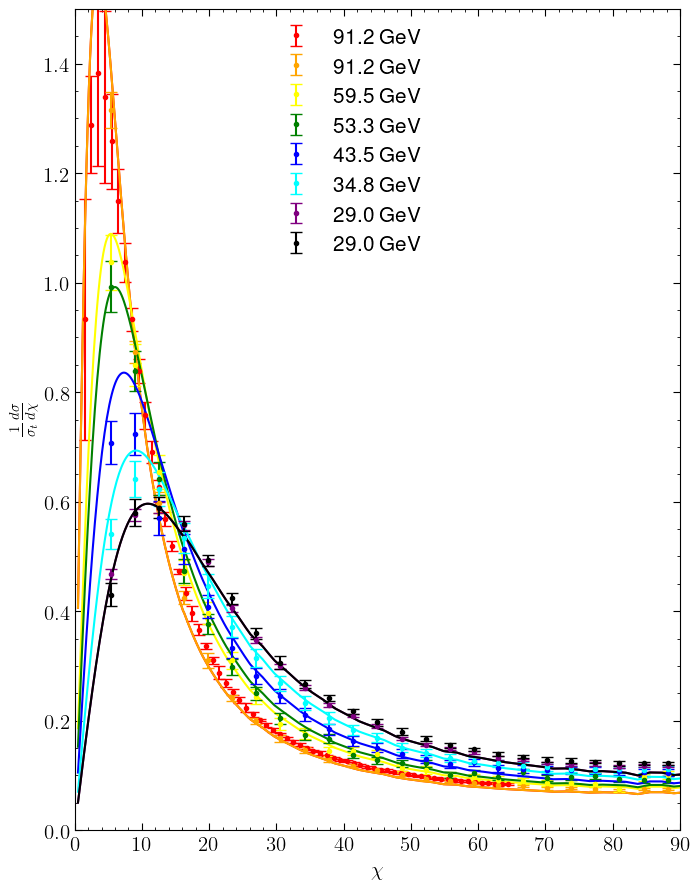

In [17]:
fig, ax1 = plt.subplots(1, 1, figsize=(7, 9)) 

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","yellow","green","blue","cyan","purple","black","yellow","orange"]
i=0
for name in dataset_names:
    ax1.errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(Q_list[name]) + " GeV", color=color[i], capsize=4,markersize=3)
    ax1.plot(xlist, v[name], color=color[i])
    i=i+1

ax1.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_t} \frac{d \sigma}{d \chi}$",fontsize=sizeOfFont)
ax1.legend()

ax1.minorticks_on()
ax1.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
ax1.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
ax1.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.3, 1))

props = dict(boxstyle='round', facecolor='white', alpha=0)
#ax1.text(0.4, 0.95,  r"\rm $ \mathrm{Q}= 91.2 \mathrm{GeV} $", transform=ax1.transAxes, fontsize=sizeOfFont,
#verticalalignment='top', bbox=props)

plt.ylim(0.0,1.5)
plt.xlim(0.0,χ_up)

plt.tight_layout()  
plt.show()

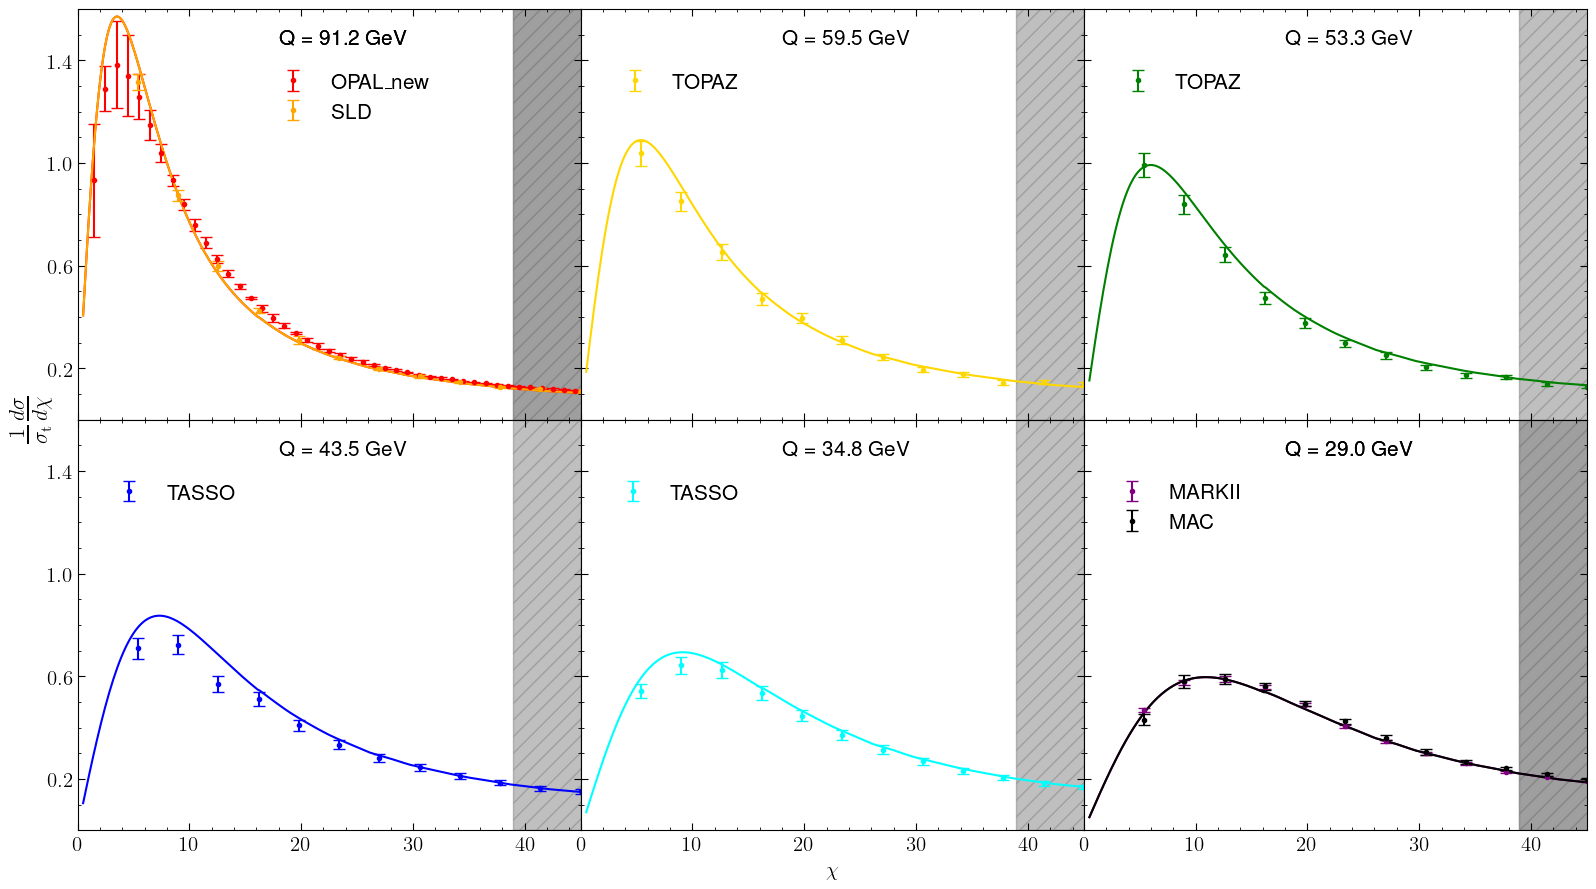

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(xlist, v[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            #χ_peak = np.arccos(1-2*(kt_lower/Q_list[name])**2)*180/np.pi
            χ_peak = np.arccos(1-2*(sqrtz_cut)**2)*180/np.pi
            #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
            ax_list[i].axvspan(χ_peak, 90, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,45)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

KeyError: 'OPAL_new'

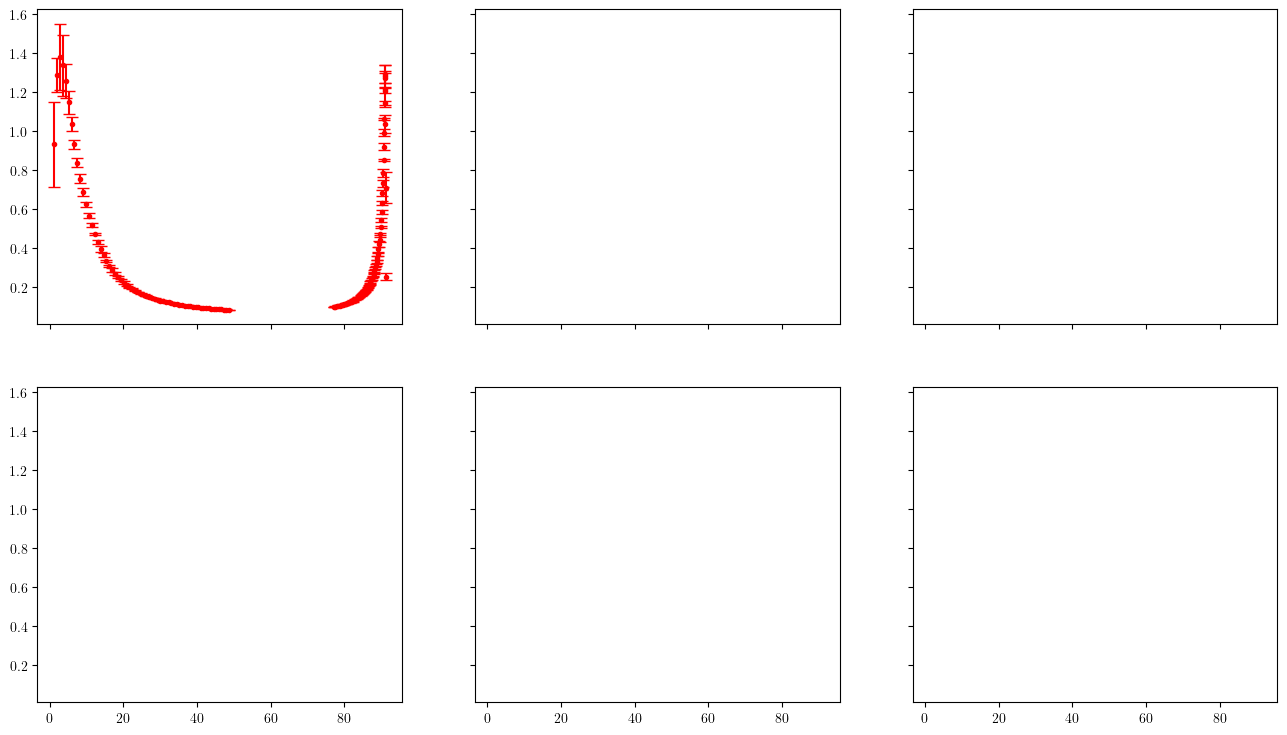

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]  = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            kt_data = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)*Q_list[name] 
            kt_list = np.sqrt((1-np.cos(xlist))/2)*Q_list[name] 
            ax_list[i].errorbar(kt_data, df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(kt_list, v[name]+non_singular[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top')
            kt_up_bound = np.sqrt((1-np.cos(χ_up*np.pi/180))/2)*Q_list[name]
            kt_low_bound = np.sqrt((1-np.cos(χ_low*np.pi/180))/2)*Q_list[name]
            #ax_list[i].axvline(x=χ_peak, color='black', linestyle='--')
            ax_list[i].axvspan(kt_up_bound, 20, color='gray', alpha=0.5, hatch='//')
            ax_list[i].axvspan(kt_upper, 20, color='gray', alpha=0.5, hatch='//')            
            #ax_list[i].axvspan(0, kt_low_bound, color='gray', alpha=0.5, hatch='//')            
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $k_T$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.55, 0.89))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.0, 1.6)
plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0,20)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

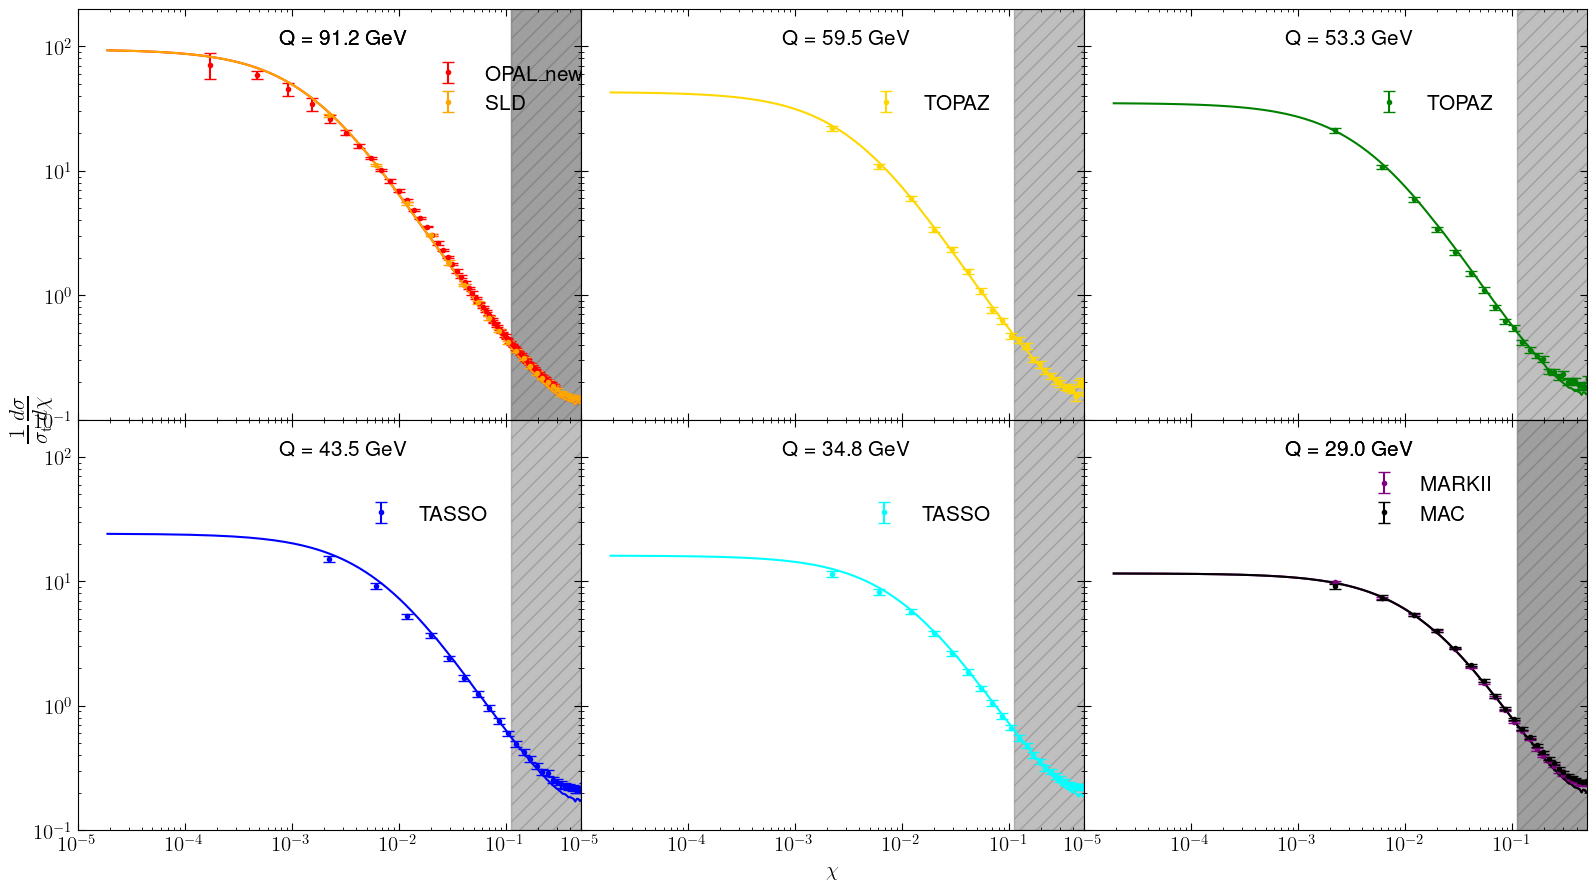

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15

color = ["red","orange","gold","green","blue","cyan","purple","black","yellow","green"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0,22.0,14.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["OPAL_new"]      = "OPAL_new"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"
name_set["TASSO_220"] = "TASSO"
name_set["TASSO_140"] = "TASSO"

i=0
j=0

predictionz={}

for Q in Q_set:
    for name in dataset_names:

        df[name]["z"] = (1-np.cos(df[name]["CHI"]*np.pi/180))/2
        df[name]["EECz"] = 2/np.sin(df[name]["CHI"]*np.pi/180)*df[name]["EEC"]
        df[name]["ERRORz"] = 2/np.sin(df[name]["CHI"]*np.pi/180)*df[name]["ERROR"]       
        predictionz[name] = 2/np.sin(xlist*np.pi/180)*(v[name])
        zlist = (1-np.cos(xlist*np.pi/180))/2

        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["z"], df[name]["EECz"], df[name]["ERRORz"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].plot(zlist, predictionz[name], color=color[j])
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            z_peak = sqrtz_cut**2
            ax_list[i].axvspan(z_peak, 1, color='gray', alpha=0.5, hatch='//')
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.85, 0.7))
    #ax.axvline(x=χ_upper)

props = dict(boxstyle='round', facecolor='white', alpha=0)

plt.ylim(0.1, 200.0)
#plt.yticks([0.2,0.6,1.0,1.4])

plt.xlim(0.00001,0.5)
plt.xscale("log")
plt.yscale("log")

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()

In [25]:
average_error={}

for name in dataset_names:
    l = len(χ[name])
    average_error[name]=round(np.sum(df_truncated[name]["ERROR"]**2)**0.5/l,4)

display(average_error)

{'OPAL': np.float64(0.0026),
 'SLD': np.float64(0.0039),
 'TOPAZ_595': np.float64(0.0063),
 'TOPAZ_533': np.float64(0.006),
 'TASSO_435': np.float64(0.0066),
 'TASSO_348': np.float64(0.0066),
 'MARKII': np.float64(0.0022),
 'MAC': np.float64(0.0042)}